# **BLIP와 LLaVA**

## 1.환경준비

* 설치

In [ ]:
!pip install -U "transformers>=4.40,<4.48" accelerate pillow sentencepiece einops -q

* 라이브러리 로딩

In [18]:
import matplotlib.pyplot as plt
import numpy as np

from transformers import pipeline
import torch
from PIL import Image

import tqdm as notebook_tqdm

# 디바이스 준비
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2.BLIP 사용해보기

### (1) 이미지 캡셔닝

* 이미지 → 텍스트 캡션 파이프라인 준비

In [19]:
cap_pipe = pipeline(
    task="image-to-text",
    model="Salesforce/blip-image-captioning-base",
    device=device
)

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\transformers\models\auto\modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
Device set to use cuda


* 테스트 파일 준비

In [ ]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 cat_bird.jpg 선택

* 이미지 캡셔닝 테스트

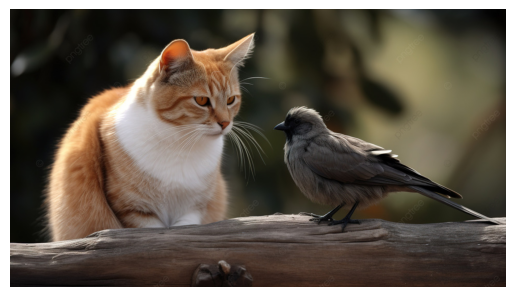

Caption: a cat and a bird are sitting on a log


In [6]:
# 테스트용 이미지 경로
img_path = "./data/cat_bird.jpg"   # 로컬에 있는 이미지 파일로 바꿔주세요

img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

# 캡션 생성
cap = cap_pipe(img_path, max_new_tokens=30)[0]["generated_text"]
print("Caption:", cap)

### (2) Vision QA

* 시각 질의응답 모델 파이프라인

In [22]:
vqa_pipe = pipeline(
    task="visual-question-answering",
    model="Salesforce/blip-vqa-base",
    device=device
)

Device set to use cuda


* 테스트 파일 준비

In [ ]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 beach_children.jpg 선택

* VQA 테스트

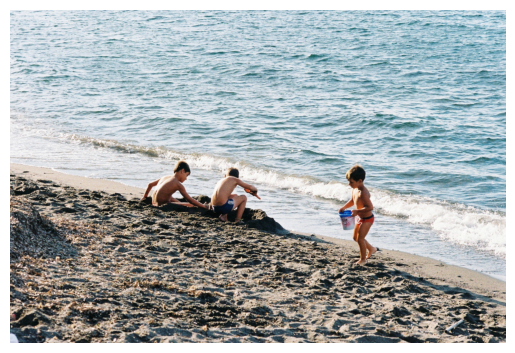

Q: What are they doing?
A: playing



In [23]:
# VQA 질문 준비
img_path = "./data/beach_children.jpg"
questions = ["What are they doing?"]

img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

for q in questions:
    ans = vqa_pipe(image=img_path, question=q)[0]["answer"]
    print(f"Q: {q}\nA: {ans}\n")

### (3) 실습
* 이미지를 한장 업로드해서 이미지 캡셔닝 및 VQA를 수행해 봅니다.

In [ ]:
from google.colab import files
uploaded = files.upload()
img_path2 = "your_image.jpg"

* 이미지 캡셔닝

Caption: [{'answer': 'circle'}]


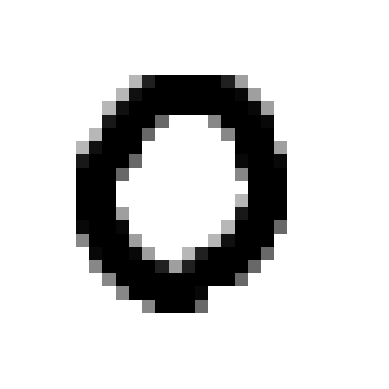

In [12]:
img_path2 = "./data/0.png"
img2 = Image.open(img_path2)

question = "What is in this picture?"
cap = vqa_pipe({"image": img2, "question": question})
print("Caption:", cap)

img = Image.open(img_path2).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()


* Vision QA

In [ ]:
img_path = "./data/0.png"
img = Image.open(img_path)

# VQA 질문 준비
questions = [
    "What is in this picture?",
    "What color is the object?",
    "Is it indoors or outdoors?",
    "How many objects are there?"
]

for q in questions:
    result = vqa_pipe({"image": img, "question": q})
    ans = result[0]['answer']  # 결과에서 답변 추출
    print(f"Q: {q}\nA: {ans}\n")

Q: What is in this picture?
A: circle

Q: What color is the object?
A: black

Q: Is it indoors or outdoors?
A: outdoors

Q: How many objects are there?
A: 1



## 3.LLaVA 사용해보기

* tiny-llava 모델은 pipeline 함수로 지원 안됨

### (1) 모델 다운로드

In [11]:
from transformers import AutoProcessor, LlavaForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model_id = "bczhou/tiny-llava-v1-hf"

model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    low_cpu_mem_usage=True,
).to(device)

processor = AutoProcessor.from_pretrained(model_id)

Loading checkpoint shards: 100%|██████████| 2/2 [00:07<00:00,  3.56s/it]


### (2) 모델 사용

In [12]:
# 버전 문제로 인한 오류 조치(미봉책)--------
ps = getattr(getattr(model.config, "vision_config", None), "patch_size", None) or 14
if getattr(processor, "patch_size", None) is None:
    processor.patch_size = ps
if getattr(processor, "num_additional_image_tokens", None) is None:
    nat = getattr(getattr(model.config, "mm_projector_config", None), "num_additional_image_tokens", None)
    processor.num_additional_image_tokens = nat if nat is not None else 1

In [14]:
img = Image.open("./data/beach_children.jpg").convert("RGB")
prompt = "USER: <image>\nWhat do you see in this picture?\nASSISTANT:"   # <image> 꼭 포함!

# 전처리 → 생성 (인자 순서 주의: text 먼저, image 다음)
inputs = processor(text=prompt, images=img, return_tensors="pt").to(device)

with torch.inference_mode():
    output_ids = model.generate(**inputs, max_new_tokens=200, do_sample=False)

# 디코딩 (프롬프트 길이만큼 잘라서 답변만 출력)
answer = processor.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print(answer)

The image features a group of three young boys playing on a sandy beach near the ocean. They are all standing on the beach, enjoying their time together. One of the boys is holding a frisbee, possibly preparing to throw it to another boy.

The beach is filled with various objects, such as a surfboard, a backpack, and a handbag. There are also two boats visible in the water, one closer to the left side of the scene and the other further away on the right side. The scene captures a fun and lively atmosphere as the boys engage in their playtime on the beach.


### (3) 실습
* BLIP 실습에서 업로드한 이미지를 사용합니다.
* VQA를 위한 프롬프트를 작성하여 결과를 확인해 봅시다.

In [15]:
img = Image.open("./data/0.png").convert("RGB")
prompt = "USER: <image>\nWhat do you see in this picture?\nASSISTANT:"   # <image> 꼭 포함!

inputs = processor(text=prompt, images=img, return_tensors="pt").to(device)

with torch.inference_mode():
    output_ids = model.generate(**inputs, max_new_tokens=200, do_sample=False)

answer = processor.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print(answer)

The image features a black and white circle with a white circle inside it. The circle inside the circle is a black circle, and the black circle is surrounded by a white circle. The black circle is positioned at the center of the image, while the white circle is located on the left side. The white circle is positioned at the top of the image, and the black circle is positioned at the bottom.


## 4.BLIP와 LLaVA 비교

### (1) 테스트 이미지와 질문 준비

In [16]:
# 이미 업로드한 파일 사용
img_path = "./data/beach_children.jpg"
img = Image.open(img_path).convert("RGB")
questions = ["What is in the image?", "How many people are there?", "Describe the scene."]

### (2) 두 모델 비교

In [24]:
#  BLIP 실행
print("=== BLIP (Salesforce/blip-vqa-base) ===================")
for q in questions:
    ans = vqa_pipe(img, q, max_new_tokens=32)[0]["answer"]
    print(f"Q: {q}\nA: {ans}\n")

#  LLaVA 실행
print("=== LLaVA (bczhou/tiny-llava-v1-hf) ===================")
for q in questions:
    prompt = f"USER: <image>\n{q}\nASSISTANT:"
    inputs = processor(text=prompt, images=img, return_tensors="pt").to(
        device,
        torch.float16 if torch.cuda.is_available() else torch.float32
    )
    with torch.inference_mode():
        out_ids = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    answer = processor.decode(out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"Q: {q}\nA: {answer}\n")

=== BLIP (Salesforce/blip-vqa-base) ===================
Q: What are they doing?
A: playing

=== LLaVA (bczhou/tiny-llava-v1-hf) ===================
Q: What are they doing?
A: The three boys are playing on the beach, with one of them holding a frisbee. They are enjoying their time together and having fun in the sand.



### (3) 실습
새로운 이미지를 찾아서 비교해 봅시다

* 이미지 업로드 및 저장

In [25]:
# from google.colab import files
# uploaded = files.upload()   # 로컬 PC에서 cat_bird.jpg 선택

img_path = "./data/dog.jpg"

* 테스트 질문 저장

In [26]:
questions = [
    "What is in this picture?",
    "What color is the object?",
    "Is it indoors or outdoors?",
    "How many objects are there?"
]

* 모델 비교

In [27]:
#  BLIP 실행
print("=== BLIP (Salesforce/blip-vqa-base) ===================")
for q in questions:
    ans = vqa_pipe(img, q, max_new_tokens=32)[0]["answer"]
    print(f"Q: {q}\nA: {ans}\n")

#  LLaVA 실행
print("=== LLaVA (bczhou/tiny-llava-v1-hf) ===================")
for q in questions:
    prompt = f"USER: <image>\n{q}\nASSISTANT:"
    inputs = processor(text=prompt, images=img, return_tensors="pt").to(
        device,
        torch.float16 if torch.cuda.is_available() else torch.float32
    )
    with torch.inference_mode():
        out_ids = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    answer = processor.decode(out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"Q: {q}\nA: {answer}\n")

=== BLIP (Salesforce/blip-vqa-base) ===================
Q: What is in this picture?
A: beach

Q: What color is the object?
A: blue

Q: Is it indoors or outdoors?
A: outdoors

Q: How many objects are there?
A: 2

=== LLaVA (bczhou/tiny-llava-v1-hf) ===================
Q: What is in this picture?
A: The image features a group of three young boys playing on a sandy beach near the ocean. They are enjoying themselves, with one boy standing on the beach and the other two boys sitting on the sand. The boys are engaged in various activities, such as throwing a frisbee and playing with a blue bucket.

The beach is a beautiful setting, with the ocean visible in the background, creating a serene and relaxing atmosphere for the children.

Q: What color is the object?
A: The object is blue.

Q: Is it indoors or outdoors?
A: It is outdoors, as the children are playing on the beach.

Q: How many objects are there?
A: There are three objects in the image: two boys and a bucket.



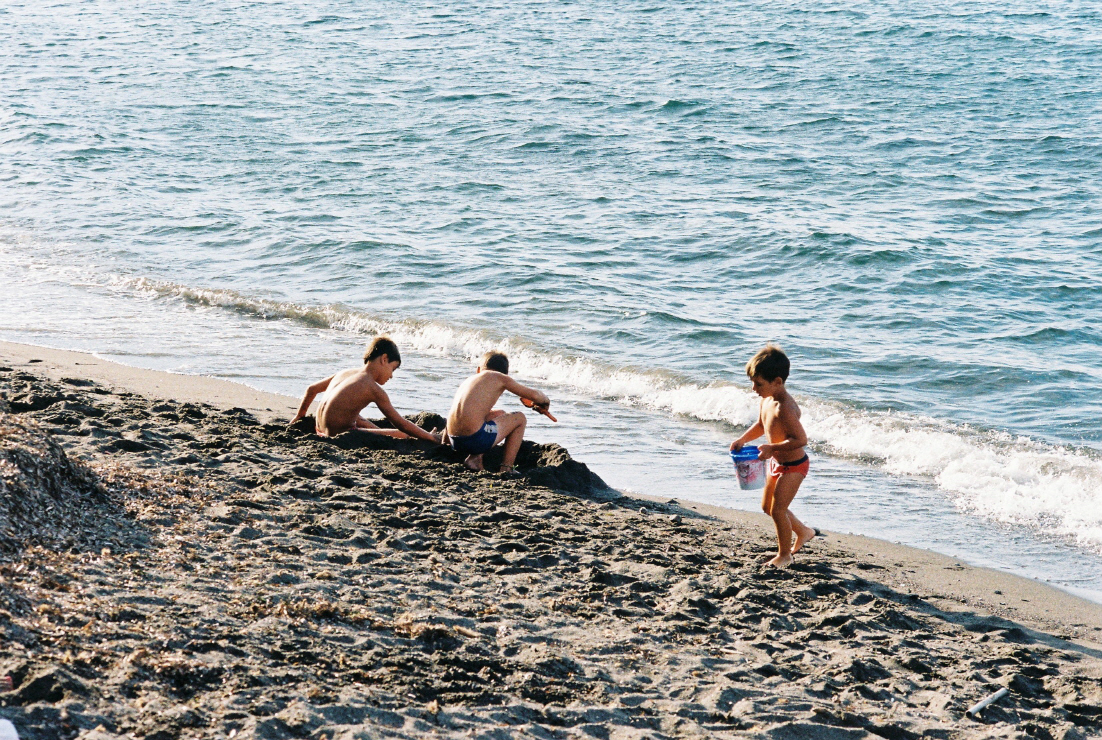

In [28]:
img